In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
#device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
#Variables
T=1000
img_size=28
batch_size=128
epochs=20
lr=1e-3
base_channels=64 #used in unet training

In [4]:
#dataset

transform_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2 -1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_1)

train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [5]:
#Forward diffusion parameters
betas=torch.linspace(1e-4,0.02,T)
alphas=1-betas
alpha_bars=torch.cumprod(alphas,dim=0).to(device)

In [6]:
def forward_diffusion(x0,t):
  noise = torch.randn_like(x0)

  # Ensure alpha_bars is on the same device as t for indexing
  alpha_bars_on_t_device = alpha_bars.to(t.device)
  sqrt_ab=torch.sqrt(alpha_bars_on_t_device[t])[:,None,None,None]
  sqrt_one_minus_ab=torch.sqrt(1-alpha_bars_on_t_device[t])[:,None,None,None]

  xt=sqrt_ab * x0 + sqrt_one_minus_ab * noise

  return xt,noise


In [7]:
#Time Embedding
class TimeEmbedding(nn.Module):
    def __init__(self,dim):
        super(TimeEmbedding,self).__init__()
        self.dim=dim

    def forward(self,t):
      half=self.dim//2
      freqs=torch.exp(-math.log(10000)*(torch.arange(half,device=t.device)/(half-1)))

      args=t[:, None]+ freqs[None,:]
      output=torch.cat([torch.sin(args),torch.cos(args)], dim=1)

      return output

In [8]:
# #ResBlock

# class ResBlock(nn.Module):
#     def __init__(self,in_ch,out_ch,time_dim):
#       super().__init__()
#       self.norm1=nn.GroupNorm(32,in_ch)
#       self.conv1=nn.Conv2d(in_ch,out_ch,3,padding=1)

#       self.norm2=nn.GroupNorm(32,out_ch)
#       self.conv2=nn.Conv2d(out_ch,out_ch,3,padding=1)

#       self.time_proj=nn.Linear(time_dim,out_ch)
#       self.skip=nn.Conv2d(in_ch,out_ch, 1) if in_ch!=out_ch else nn.Identity()

#     def forward(self,x):
#       h=self.conv1(torch.relu(self.norm1(x)))

#       h=h+ self.time_proj(t)[:, :, None,None]

#       h=self.conv2(torch.relu(self.norm2(h)))

#       return h+self.skip



In [9]:
#ResBlock

class ResBlock(nn.Module):
    def __init__(self,in_ch,out_ch,time_dim):
      super().__init__()
      self.norm1=nn.GroupNorm(32,in_ch)
      self.conv1=nn.Conv2d(in_ch,out_ch,3,padding=1)

      self.norm2=nn.GroupNorm(32,out_ch)
      self.conv2=nn.Conv2d(out_ch,out_ch,3,padding=1)

      self.time_proj=nn.Linear(time_dim,out_ch)
      self.skip=nn.Conv2d(in_ch,out_ch,kernel_size=1) if in_ch!=out_ch else nn.Identity()

    def forward(self,x,t):
      h=self.conv1(torch.relu(self.norm1(x)))

      h=h+ self.time_proj(t)[:, :, None,None]

      h=self.conv2(torch.relu(self.norm2(h)))

      return h+self.skip(x)


In [10]:
#Attention block

class AttentionBlock(nn.Module):
  def __init__(self, ch):
     super().__init__()

     self.norm=nn.GroupNorm(32,ch)
     self.q=nn.Conv2d(ch,ch,1)
     self.k=nn.Conv2d(ch,ch,1)
     self.v=nn.Conv2d(ch,ch,1)

     self.proj=nn.Conv2d(ch,ch,1)

  def forward(self,x):
    B,C,H,W=x.shape

    h=self.norm(x)


    q=self.q(h).reshape(B,C,H*W)
    k=self.k(h).reshape(B,C,H*W)
    v=self.v(h).reshape(B,C,H*W)

    attn=torch.softmax(q.transpose(1,2)@k / math.sqrt(C), dim=-1)
    h=(attn @ v.transpose(1,2)) .transpose(1,2).reshape(B,C,H,W)

    return x+ self.proj(h)


In [11]:
# import torch.nn as nn

# class DDPMUNet(nn.Module):
#   def __init__(self):
#      super().__init__()
#      time_dim=base_channels*4

#      self.time_mlp=nn.Sequential(
#          TimeEmbedding(base_channels),
#          nn.Linear(base_channels,time_dim),
#          nn.ReLU(),
#          nn.Linear(time_dim,time_dim)
#      )

#      self.conv_in=nn.Conv2d(1,base_channels,3,padding=1)

#      self.res1=ResBlock(base_channels,base_channels,time_dim)

#      #down
#      self.down1=ResBlock(base_channels,base_channels,time_dim)
#      self.down2=ResBlock(base_channels,base_channels *2 ,time_dim)
#      self.pool=nn.AvgPool2d(2)

#      #bottleneck
#      self.mid1=ResBlock(base_channels*2,base_channels*2,time_dim)
#      self.attn=AttentionBlock(base_channels*2)
#      self.mid2=ResBlock(base_channels*2,base_channels*2,time_dim)

#      #up
#      self.up=nn.Upsample(scale_factor = 2, mode="nearest")
#      self.up1=ResBlock(base_channels*2,base_channels,time_dim)
#      self.up2=ResBlock(base_channels*2,base_channels,time_dim)

#      self.conv_out=nn.Conv2d(base_channels,1,3,padding=1)

#   def forward(self,x,t):
#     t=self.time_mlp(t.float())

#     x=self.conv_in(x)

#     d1=x
#     d2=self.down1(d1,t)
#     h=self.pool(d2)

#     print(f"Shape of h before self.down2: {h.shape}") # Added print statement
#     # Apply self.down2 to increase channels from base_channels to base_channels*2
#     h=self.down2(h, t)
#     print(f"Shape of h after self.down2: {h.shape}")  # Added print statement

#     h=self.mid1(h,t)
#     h=self.attn(h)
#     h=self.mid2(h,t)

#     h=self.up(h)
#     h=self.up1(h, t) # Corrected: Pass 't' to self.up1
#     h=torch.cat([h,d1],dim=1)
#     h=self.up2(h,t)

#     h=self.conv_out(h)

#     return h

In [12]:
import torch.nn as nn

class DDPMUNet(nn.Module):
  def __init__(self):
     super().__init__()
     time_dim=base_channels*4

     self.time_mlp=nn.Sequential(
         TimeEmbedding(base_channels),
         nn.Linear(base_channels,time_dim),
         nn.ReLU(),
         nn.Linear(time_dim,time_dim)
     )

     self.conv_in=nn.Conv2d(1,base_channels,3,padding=1)

     self.res1=ResBlock(base_channels,base_channels,time_dim)

     #down
     self.down1=ResBlock(base_channels,base_channels,time_dim)
     self.down2=ResBlock(base_channels,base_channels *2 ,time_dim)
     self.pool=nn.AvgPool2d(2)

     #bottleneck
     self.mid1=ResBlock(base_channels*2,base_channels*2,time_dim)
     self.attn=AttentionBlock(base_channels*2)
     self.mid2=ResBlock(base_channels*2,base_channels*2,time_dim)

     #up
     self.up=nn.Upsample(scale_factor = 2, mode="nearest")
     self.up1=ResBlock(base_channels*2,base_channels,time_dim)
     self.up2=ResBlock(base_channels*2,base_channels,time_dim)

     self.conv_out=nn.Conv2d(base_channels,1,3,padding=1)

  def forward(self,x,t):
    t=self.time_mlp(t.float())

    x=self.conv_in(x)

    d1=x
    d2=self.down1(d1,t)
    h=self.pool(d2)

    h=self.down2(h, t)

    h=self.mid1(h,t)
    h=self.attn(h)
    h=self.mid2(h,t)

    h=self.up(h)
    h=self.up1(h, t) # Corrected: Pass 't' to self.up1
    h=torch.cat([h,d1],dim=1)
    h=self.up2(h,t)

    h=self.conv_out(h)

    return h

In [13]:
from torch.optim import optimizer
model = DDPMUNet().to(device)
optimizer=optim.AdamW(model.parameters(), lr=lr)


In [14]:
for epoch in range(epochs):
  epoch_loss = 0.0
  for x, _ in train_loader:

    x=x.to(device)
    t=torch.randint(0,T,(x.shape[0],), device=device)
    xt, noise =forward_diffusion(x,t)

    noise_pred=model(xt,t)

    loss=((noise_pred - noise ) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")


Epoch 1/20 | Loss: 0.0854
Epoch 2/20 | Loss: 0.0381
Epoch 3/20 | Loss: 0.0336
Epoch 4/20 | Loss: 0.0313
Epoch 5/20 | Loss: 0.0305
Epoch 6/20 | Loss: 0.0299
Epoch 7/20 | Loss: 0.0294
Epoch 8/20 | Loss: 0.0282
Epoch 9/20 | Loss: 0.0281
Epoch 10/20 | Loss: 0.0273
Epoch 11/20 | Loss: 0.0272
Epoch 12/20 | Loss: 0.0271
Epoch 13/20 | Loss: 0.0269
Epoch 14/20 | Loss: 0.0266
Epoch 15/20 | Loss: 0.0264
Epoch 16/20 | Loss: 0.0262
Epoch 17/20 | Loss: 0.0261
Epoch 18/20 | Loss: 0.0257
Epoch 19/20 | Loss: 0.0255
Epoch 20/20 | Loss: 0.0254


In [15]:
@torch.no_grad()
def sample(model, n_samples=16):
    model.eval()

    # schedule tensors all on the same device
    betas_d      = betas.to(device)
    alphas_d     = alphas.to(device)
    alpha_bars_d = alpha_bars.to(device)

    # start from pure Gaussian noise: x_T
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for i in reversed(range(T)):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)

        eps = model(x, t)                      # predicted noise

        beta_t      = betas_d[i]
        alpha_t     = alphas_d[i]
        alpha_bar_t = alpha_bars_d[i]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * eps)

        if i > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise   # add noise except at the last step
        else:
            x = mean

    model.train()
    return x

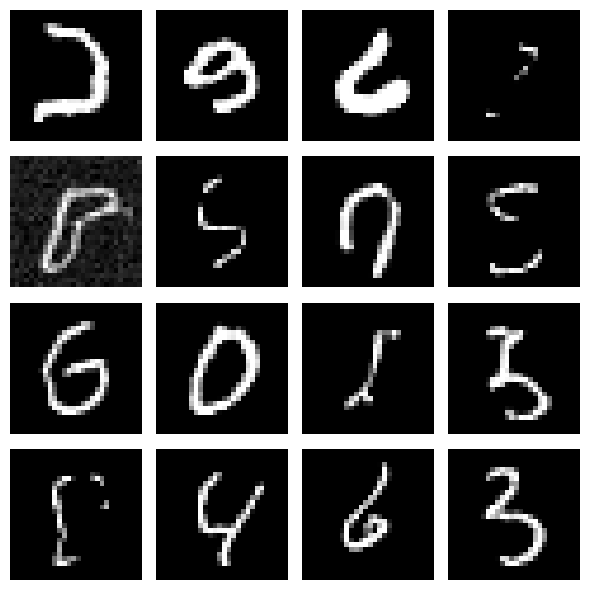

In [16]:
# Visualization

samples = sample(model, n_samples=16)

# undo the [-1, 1] normalization your transform applied (x*2 - 1) → back to [0, 1]
samples = (samples.clamp(-1, 1) + 1) / 2
samples = samples.cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img in zip(axes.flatten(), samples):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()